In [52]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils import data
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
import time
from IPython import display

In [32]:
def batch_norm(X,gamma,beta,moving_mean,moving_var,eps,momentum):
    # 通过is_grad_enabled方法来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean)/torch.sqrt(moving_var+eps)
    else:
        assert len(X.shape) in (2,4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X-mean)**2).mean(dim=0)
        else:
            #使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差
            #这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0,2,3),keepdim=True)
            var = ((X-mean)**2).mean(dim=(0,2,3),keepdim=True)
        #训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean)/torch.sqrt(var+eps)
        #更新移动平均的均值和方差
        moving_mean = momentum*moving_mean + (1.0-momentum)*mean
        moving_var = momentum*moving_var + (1.0-momentum)*var
    Y = gamma*X_hat + beta  #缩放和移位
    return Y,moving_mean.data,moving_var.data

In [41]:
class BatchNorm(nn.Module):
    # num_features:全连接层的输出数量或卷积层的输出通道数
    # num_dims:2表示全连接层，4表示卷积层
    def __init__(self,num_features,num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1,num_features)
        else:
            shape = (1,num_features,1,1)
        # 参与求梯度和迭代的拉伸参数和偏移参数，其分别初始化成1和0
        self.gama = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 非模型参数的变量初始化为0和1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self,X):
        # 如果X不在内存上，将moving_mean和moving_var复制到X所在的显存上
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 保存更新过的moving_mean和moving_var
        Y,self.moving_mean,self.moving_var = batch_norm(X,self.gama,self.beta,self.moving_mean,self.moving_var,eps=1e-5,momentum=0.9)
        return Y

In [42]:
net = nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5),BatchNorm(6,num_dims=4),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),BatchNorm(16,num_dims=4),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),nn.Flatten(),
    nn.Linear(16*4*4,120),BatchNorm(120,num_dims=2),nn.Sigmoid(),
    nn.Linear(120,84),BatchNorm(84,num_dims=2),nn.Sigmoid(),
    nn.Linear(84,10))

In [57]:
# 获取模型所在设备
device = next(net.parameters()).device
# 创建输入并移到该设备
X = torch.rand(size=(1, 1, 28, 28)).to(device)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 6, 24, 24])
BatchNorm output shape:	 torch.Size([1, 6, 24, 24])
Sigmoid output shape:	 torch.Size([1, 6, 24, 24])
AvgPool2d output shape:	 torch.Size([1, 6, 12, 12])
Conv2d output shape:	 torch.Size([1, 16, 8, 8])
BatchNorm output shape:	 torch.Size([1, 16, 8, 8])
Sigmoid output shape:	 torch.Size([1, 16, 8, 8])
AvgPool2d output shape:	 torch.Size([1, 16, 4, 4])
Flatten output shape:	 torch.Size([1, 256])
Linear output shape:	 torch.Size([1, 120])
BatchNorm output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
BatchNorm output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


In [43]:
def get_dataloader_workers():
    return 4

def load_data_fashion_mnist(batch_size,resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(root="./data",train=True,transform=trans,download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root="./data",train=False,transform=trans,download=True)
    return (data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers = get_dataloader_workers()),data.DataLoader(mnist_test,batch_size,shuffle=True,num_workers = get_dataloader_workers()))

In [44]:
# 辅助函数：计算时间
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        """启动计时器"""
        self.tik = time.time()
    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)
    def sum(self):
        """返回时间总和"""
        return sum(self.times)
    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [45]:
# 6.辅助函数：绘图用
def use_svg_display():
    """使用svg格式在jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()
    
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [49]:
# 5.辅助函数：精度计算与累加器
class Accumulator:
    def __init__(self,n):
        self.data = [0.0]*n
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data = [0.0]*len(self.data)
    def __getitem__(self,idx):
        return self.data[idx]

def accuracy(y_hat,y):
    """计算预测正确的数量"""
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:  # 如果 y_hat 的维度大于1（即是一个矩阵）并且列数大于1（即多分类问题）
        y_hat = y_hat.argmax(axis=1)  # 沿着列方向（axis=1）取最大值的索引，将概率输出转换为预测类别
    cmp = y_hat.type(y.dtype) == y  # 将预测标签 y_hat 转换为与 y 相同的数据类型（例如 int），然后与真实标签 y 逐元素比较
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy_gpu(net,data_iter,device=None):
    if isinstance(net,nn.Module):
        net.eval()  #设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = Accumulator(2)
    with torch.no_grad():
        for X,y in data_iter:
            if isinstance(X,list):
                # BERT微调所需的
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]

In [50]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    """用GPU训练模型"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on',device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(),lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch',xlim=[1,num_epochs],legend=['train loss','train acc','test acc'])
    timer,num_batches = Timer(),len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i,(X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X,y = X.to(device),y.to(device)
            y_hat = net(X)
            l = loss(y_hat,y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l*X.shape[0],accuracy(y_hat,y),X.shape[0])
            timer.stop()
            train_l = metric[0]/metric[2]
            train_acc = metric[1]/metric[2]
            if (i+1)%(num_batches//5) == 0 or i==num_batches-1:
                animator.add(epoch+(i+1)/num_batches,(train_l,train_acc,None))
        test_acc = evaluate_accuracy_gpu(net,test_iter)
        animator.add(epoch+1,(None,None,test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

def try_gpu(i=0):
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count()>=i+1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

loss 0.266, train acc 0.900, test acc 0.863
12153.2 examples/sec on cuda:0


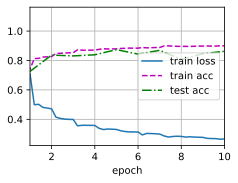

In [53]:
lr,num_epochs,batch_size=1.0,10,256
train_iter,test_iter = load_data_fashion_mnist(batch_size)
train_ch6(net,train_iter,test_iter,num_epochs,lr,try_gpu())

In [58]:
net = nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5),nn.BatchNorm2d(6),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),nn.BatchNorm2d(16),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),nn.Flatten(),
    nn.Linear(16*4*4,120),BatchNorm(120,num_dims=2),nn.Sigmoid(),
    nn.Linear(120,84),BatchNorm(84,num_dims=2),nn.Sigmoid(),
    nn.Linear(84,10))

loss 0.282, train acc 0.895, test acc 0.602
15633.4 examples/sec on cuda:0


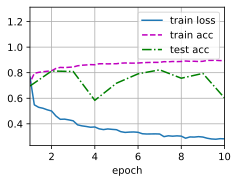

In [59]:
train_ch6(net,train_iter,test_iter,num_epochs,lr,try_gpu())